In [1]:
from tqdm import tqdm
from pprint import pprint
import numpy as np

In [2]:
# -------------------------
# Constants
# -------------------------

dataset_detail=np.load("/mnt/Extra/Project_Storage/stereo_ML_dataset/org/"+"feat_detail.npy", allow_pickle=True)
dataset_detail=dataset_detail.tolist()

patch_shape = (int(dataset_detail[0]),int(dataset_detail[1]))

target = min(int(dataset_detail[2]*0.8),int(2**18+1))
# target=1000

Dmax = int(dataset_detail[3])
Dmin = int(dataset_detail[4])

resize_fraction = dataset_detail[5]
resize_factor = 1/resize_fraction

feature_dimension =int (dataset_detail[6])

disparity_skip = int(dataset_detail[7])

eff_Dmax = (Dmax-Dmin)//(disparity_skip+1)


In [3]:

org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/feat_data/"

# -------------------------
# Load memmap datasets
# -------------------------
left_feat_memmap = dataset_org_path + "left_feat.dat"
right_feat_memmap = dataset_org_path + "right_feat.dat"
patch_disparity_memmap = dataset_org_path + "patch_disp.dat"


model_location = org_path+"model/"

patch_feat =np.memmap(left_feat_memmap, dtype=np.float32, mode='r', shape=(target, feature_dimension))

strip_feat =np.memmap(right_feat_memmap, dtype=np.float32, mode='r', shape=(target,  eff_Dmax, feature_dimension))

median_disp   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(target,))




Testing: 100%|██████████| 104859/104859 [00:01<00:00, 52914.04it/s]


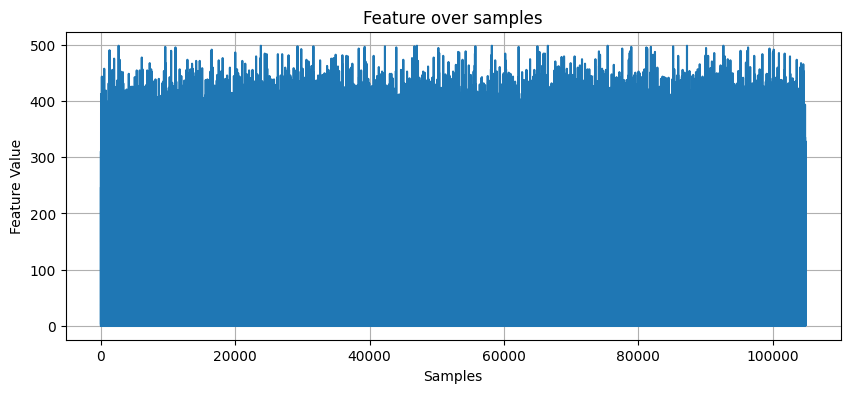

0
85.50615588552246
499


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_features_overlay(data, legend_labels=None, figsize=(10, 6)):
    
    plt.figure(figsize=figsize)
    
    x, f = data.shape
    for i in range(f):
        label = legend_labels[i] if legend_labels else f'Feature {i+1}'
        plt.plot(data[:, i], label=label)
    
    plt.xlabel('Samples (x)')
    plt.ylabel('Feature Values')
    plt.title('All Features Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()
    

def plot_single_feature(data, title="Feature over samples", figsize=(10, 4)):
    
    plt.figure(figsize=figsize)
    plt.plot(data)
    plt.xlabel('Samples')
    plt.ylabel('Feature Value')
    plt.title(title)
    plt.grid(True)
    plt.show()

# Usage examples:
# data = np.random.randn(100)  # Shape (100,)
# plot_single_feature(data, "My Feature")

def direct_test(left_feat, right_feats, true_disp):
    delta_error = []
    size = len(true_disp)

    for i in tqdm(range(size), desc="Testing"):
        # Use float32 or float64 for precision safety
        lf = left_feat[i].astype(np.float32)
        rf = right_feats[i].astype(np.float32)

        # Compute squared L2 distance in a stable way
        diff = rf - lf[None, :]
        sq_dist = np.sum(diff * diff, axis=1)

        # Use argmin of squared distance (same as normal L2)
        best_disp = np.argmin(sq_dist)
        delta = abs(best_disp - true_disp[i])
        delta_error.append(delta)

    return np.array(delta_error)


delta_error = direct_test(patch_feat,strip_feat,median_disp)
plot_single_feature(delta_error)

print(np.min(delta_error))
print(np.mean(delta_error))
print(np.max(delta_error))
        

In [4]:
def compute_delta_feature_arrays(left_feat, right_feats, true_disp, Dmax):
    
    # Feature difference
    feat_diff = right_feats - left_feat[None, :]            # shape (Dmax, F)
    
    F = left_feat.shape[0]
    
    # Initialize array to hold delta arrays for each feature
    # Use np.nan to indicate unfilled entries
    delta_arrays = np.full((F, 2*Dmax-1), np.nan, dtype=np.float32)
    
    # Fill delta arrays
    for f in range(F):
        for idx in range(Dmax):
            delta_idx = idx - true_disp + Dmax - 1  # index in 0..2*Dmax-2
            delta_arrays[f, delta_idx] = np.abs(feat_diff[idx, f])
    
    return delta_arrays


In [5]:
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

def _compute_single_sample(args):
    """Helper to compute delta arrays for one sample."""
    i, left_feat, right_feats, true_disp, Dmax = args
    return compute_delta_feature_arrays(left_feat, right_feats, true_disp, Dmax)

def compute_delta_features(F_size, left_feat, right_feats, true_disps, Dmax, num_workers=None):
    """
    Parallelized version that collects all delta arrays first,
    then averages them at the end, ignoring NaNs.
    """
    N = left_feat.shape[0]
    F = F_size

    # Prepare argument list
    args_list = [
        (i, left_feat[i].astype(np.float32),
         right_feats[i].astype(np.float32),
         true_disps[i], Dmax)
        for i in range(N)
    ]

    # Decide number of workers
    if num_workers is None:
        num_workers = max(1, cpu_count() - 1)

    # Collect all results in a list
    with Pool(processes=num_workers) as pool:
        all_results = list(tqdm(pool.imap_unordered(_compute_single_sample, args_list), total=N))

    # Stack results
    all_results = np.stack(all_results, axis=0)  # shape: (N, F, 2*Dmax-1)

    # Compute mean across samples, ignoring NaNs
    mean_delta_arrays = np.nanmean(all_results, axis=0)  # shape: (F, 2*Dmax-1)

    return mean_delta_arrays


In [11]:
F_size = feature_dimension


mean_feature_errors = compute_delta_features(F_size, patch_feat, strip_feat, median_disp, eff_Dmax)

print(mean_feature_errors.shape)

100%|██████████| 80/80 [00:00<00:00, 872.09it/s]

(7, 1599)



/tmp/ipykernel_1743738/71239178.py:38: RuntimeWarning: Mean of empty slice
  mean_delta_arrays = np.nanmean(all_results, axis=0)  # shape: (F, 2*Dmax-1)


In [7]:

import matplotlib.pyplot as plt
import numpy as np
import math

def plot_delta_features(delta_array):
    """
    delta_array: np.array of shape (F, 2*Dmax-1)
                 Each row corresponds to a feature.
    
    Plots F graphs in a grid, 5 graphs per row, x-axis from -(Dmax-1) to +(Dmax-1)
    """
    F, length = delta_array.shape
    assert length % 2 == 1, "Second dimension should be odd"
    
    Dmax = (length + 1) // 2
    x = np.arange(-(Dmax-1), Dmax, 1)  # x-axis: -(Dmax-1) to +(Dmax-1)
    
    cols = 5
    rows = math.ceil(F / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten()  # Flatten in case we have multiple rows
    
    for i in range(F):
        axes[i].plot(x, delta_array[i])
        axes[i].set_title(f'Feature {i+1}')
        axes[i].set_xlabel('Delta index')
        axes[i].set_ylabel('Value')
        axes[i].grid(True)
    
    # Hide unused subplots if F is not multiple of cols
    for j in range(F, rows*cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
import matplotlib.pyplot as plt
import numpy as np

def plot_single_feature(delta_array, feature_name="Feature"):
    """
    delta_array: 1D np.array of length 2*Dmax-1
                 Represents a single feature's values across delta positions.
    
    Plots a single graph with x-axis from -(Dmax-1) to +(Dmax-1)
    """
    length = delta_array.shape[0]
    assert length % 2 == 1, "Length of array should be odd"
    
    Dmax = (length + 1) // 2
    x = np.arange(-(Dmax-1), Dmax, 1)  # x-axis: -(Dmax-1) to +(Dmax-1)
    
    plt.figure(figsize=(8,4))
    plt.plot(x, delta_array, marker='o')
    plt.title(f'{feature_name}')
    plt.xlabel('Delta index')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()



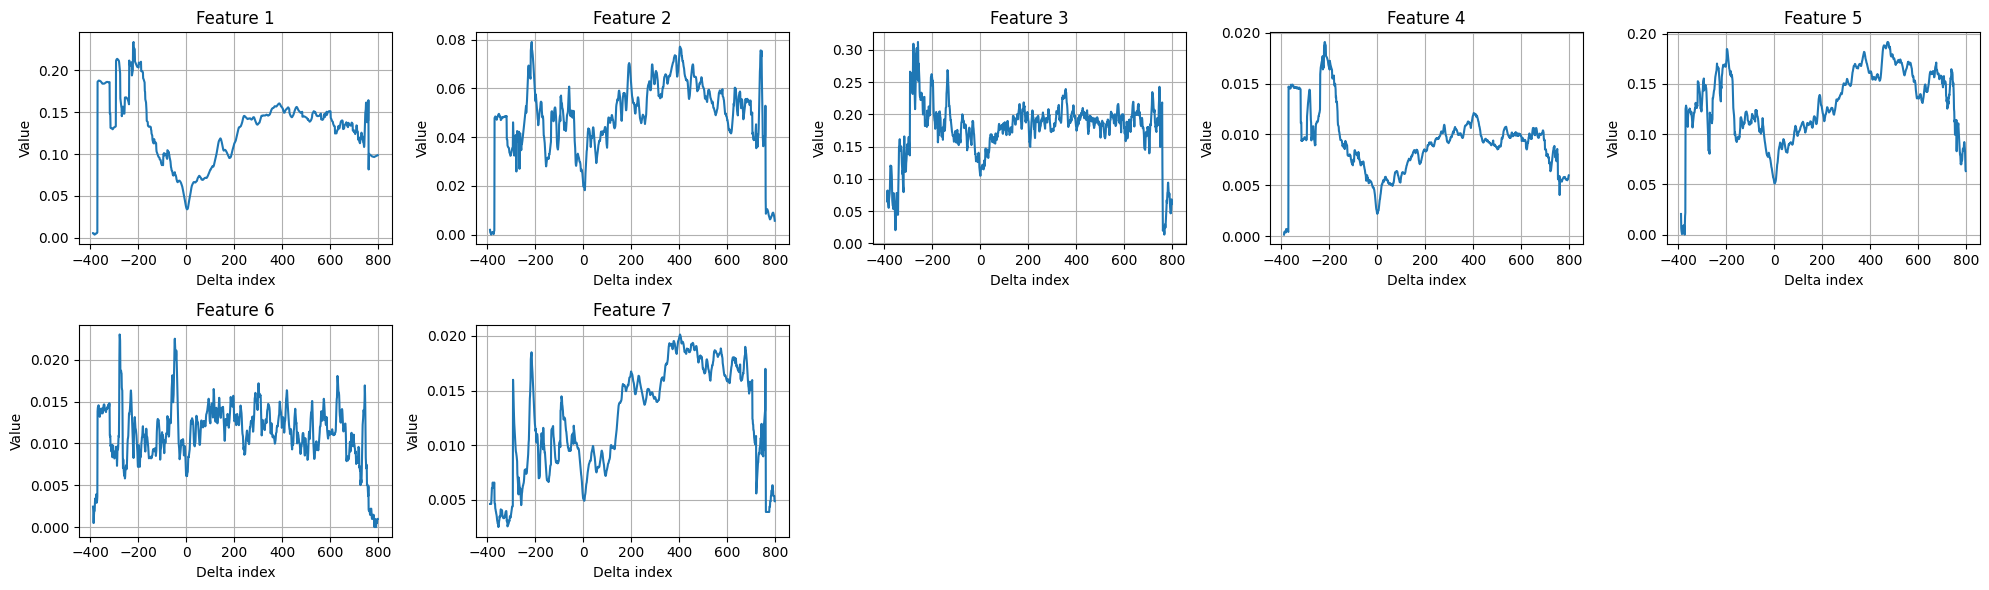

In [8]:
plot_delta_features(mean_feature_errors)

In [9]:
import numpy as np

import numpy as np

def weighted_mean_from_array(arr, baseline=None):
    """
    Compute weighted mean across features and normalize to [0,1].
    
    arr: np.ndarray of shape (F, x)
    baseline: optional array of shape (F,), baseline value of each feature. 
              If None, minimum across x is used.
    
    Returns:
        x_mean: np.ndarray of shape (x,), weighted mean normalized to [0,1]
        weights: np.ndarray of shape (F,), the calculated feature weights
    """
    F, x = arr.shape

    # Compute baseline if not provided
    if baseline is None:
        baseline = np.nanmin(arr, axis=1)  # (F,)
    
    # Compute dynamic range of each feature
    feature_range = np.nanmax(arr, axis=1) - baseline  # (F,)

    # Weight: higher range → higher weight, smaller baseline → higher weight
    weights = feature_range / (feature_range.sum() + 1e-8)
    
    # Weighted mean across features
    x_mean = np.nansum(arr * weights[:, None], axis=0)
    
    # Normalize to [0,1]
    min_val = np.nanmin(x_mean)
    max_val = np.nanmax(x_mean)
    if max_val - min_val > 0:
        x_mean = (x_mean - min_val) / (max_val - min_val)
    else:
        x_mean = np.zeros_like(x_mean)

    return x_mean, weights

valid_combined_error,weights = weighted_mean_from_array(mean_feature_errors)

print(weights)

[0.26811105 0.09196479 0.3476224  0.0220458  0.22296284 0.02679876
 0.02049442]


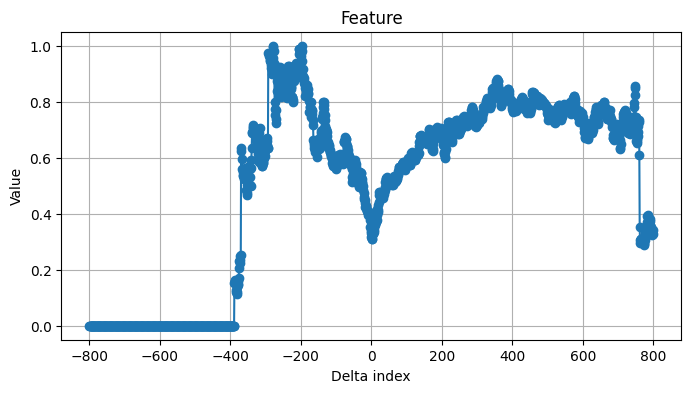



1.0
0.31080633


31.080633


In [10]:



plot_single_feature(valid_combined_error)

valid_maxima = np.nanmax(valid_combined_error)
valid_base = valid_combined_error[eff_Dmax]

print("\n")
print(valid_maxima)
print(valid_base)
print("\n")
print((valid_base/valid_maxima)*100)